In [64]:
import pandas as pd

# Use this path (no dots - just 'data/')
house_df = pd.read_csv('data/Bengaluru_House_Data.csv')

# Show the first 5 rows
house_df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [68]:
# Shows: number of rows/columns, column names, data types, and non-null counts
house_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [69]:
# Shows how many missing (empty) values are in each column
house_df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [70]:
# Drop columns we won't use
# axis=1 means "drop a column" (axis=0 would mean "drop a row")
house_df = house_df.drop(['society', 'availability'], axis=1)

# Confirm the columns are gone
house_df.columns

Index(['area_type', 'location', 'size', 'total_sqft', 'bath', 'balcony',
       'price'],
      dtype='str')

In [73]:
# Show all the different unique text values in the 'size' column
house_df['size'].unique()

<StringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',      '4 BHK',  '6 Bedroom',
  '3 Bedroom',      '1 BHK',       '1 RK',  '1 Bedroom',  '8 Bedroom',
  '2 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',          nan,  '9 Bedroom',
     '27 BHK', '10 Bedroom', '11 Bedroom',     '10 BHK',     '19 BHK',
     '16 BHK', '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',
     '13 BHK', '18 Bedroom']
Length: 32, dtype: str

In [75]:
# Create a new column 'bhk' by taking the first "word" before the space
# and converting it to an integer.
# We use a function applied to every row.

def extract_bhk(size_value):
    if pd.isnull(size_value):
        return None  # leave missing values as missing for now
    return int(size_value.split(' ')[0])

house_df['bhk'] = house_df['size'].apply(extract_bhk)

# Check the result
house_df[['size', 'bhk']].head(10)

,size,bhk
0,2 BHK,2.0
1,4 Bedroom,4.0
2,3 BHK,3.0
3,3 BHK,3.0
4,2 BHK,2.0
5,2 BHK,2.0
6,4 BHK,4.0
7,4 BHK,4.0
8,3 BHK,3.0
9,6 Bedroom,6.0


In [76]:
# A function that checks if a value can be converted directly to a float
def is_clean_number(value):
    try:
        float(value)
        return True
    except:
        return False

# Show rows where total_sqft is NOT a clean number (i.e., it's a range or has text)
house_df[~house_df['total_sqft'].apply(is_clean_number)].head(10)

,area_type,location,size,total_sqft,bath,balcony,price,bhk
30,Super built-up Area,Yelahanka,4 BHK,2100 - 2850,4.0,0.0,186.000,4.0
56,Built-up Area,Devanahalli,4 Bedroom,3010 - 3410,NaN,NaN,192.000,4.0
81,Built-up Area,Hennur Road,4 Bedroom,2957 - 3450,NaN,NaN,224.500,4.0
122,Super built-up Area,Hebbal,4 BHK,3067 - 8156,4.0,0.0,477.000,4.0
137,Super built-up Area,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,0.0,54.005,2.0
165,Super built-up Area,Sarjapur,2 BHK,1145 - 1340,2.0,0.0,43.490,2.0
188,Super built-up Area,KR Puram,2 BHK,1015 - 1540,2.0,0.0,56.800,2.0
224,Super built-up Area,Devanahalli,3 BHK,1520 - 1740,NaN,NaN,74.820,3.0
410,Super built-up Area,Kengeri,1 BHK,34.46Sq. Meter,1.0,0.0,18.500,1.0
549,Super built-up Area,Hennur Road,2 BHK,1195 - 1440,2.0,0.0,63.770,2.0


In [77]:
def convert_sqft_to_num(value):
    tokens = value.split('-')
    if len(tokens) == 2:
        # It's a range like "2100 - 2850" -> average them
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        # Try converting directly (handles clean numbers like "1200")
        return float(value)
    except:
        # Anything else weird (e.g. "34.46Sq. Meter") -> None
        return None

house_df['total_sqft'] = house_df['total_sqft'].apply(convert_sqft_to_num)

# Check how many became None (couldn't be converted)
house_df['total_sqft'].isnull().sum()

np.int64(46)

In [78]:
# Drop rows with missing location, total_sqft, or bhk
house_df = house_df.dropna(subset=['location', 'total_sqft', 'bhk'])

# Fill missing bath and balcony with the median value of that column
house_df['bath'] = house_df['bath'].fillna(house_df['bath'].median())
house_df['balcony'] = house_df['balcony'].fillna(house_df['balcony'].median())

# Confirm: no missing values left anywhere
house_df.isnull().sum()

area_type     0
location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
bhk           0
dtype: int64

In [79]:
house_df = house_df.drop('size', axis=1)

# Let's also check the shape now, and look at the cleaned data
print(house_df.shape)
house_df.head()

(13257, 7)


,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2.0


In [80]:
# price is in lakhs, total_sqft is in square feet
# This gives us price per square foot (still in lakh units, just for comparison)
house_df['price_per_sqft'] = (house_df['price'] * 100000) / house_df['total_sqft']

house_df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0,3699.810606
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0,4615.384615
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3.0,4305.555556
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0,6245.890861
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2.0,4250.000000


In [81]:
house_df['price_per_sqft'].describe()

count    1.325700e+04
mean     7.912825e+03
std      1.064976e+05
min      2.678298e+02
25%      4.271186e+03
50%      5.438596e+03
75%      7.313318e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [83]:
# Check how many rows violate this rule
unrealistic = house_df[house_df['total_sqft'] / house_df['bhk'] < 300]
print(f"Number of unrealistic rows: {len(unrealistic)}")
unrealistic.head()

Number of unrealistic rows: 744


,area_type,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
9,Plot Area,Gandhi Bazar,1020.0,6.0,2.0,370.0,6.0,36274.509804
45,Plot Area,HSR Layout,600.0,9.0,2.0,200.0,8.0,33333.333333
58,Plot Area,Murugeshpalya,1407.0,4.0,1.0,150.0,6.0,10660.980810
68,Plot Area,Devarachikkanahalli,1350.0,7.0,0.0,85.0,8.0,6296.296296
70,Plot Area,Double Road,500.0,3.0,2.0,100.0,3.0,20000.000000


In [84]:
# Keep only rows where total_sqft / bhk >= 300 (realistic homes)
house_df = house_df[~(house_df['total_sqft'] / house_df['bhk'] < 300)]

print(house_df.shape)
house_df['price_per_sqft'].describe()

(12513, 8)


count     12513.000000
mean       6307.441644
std        4160.931610
min         267.829813
25%        4210.526316
50%        5295.007564
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [85]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()  # empty DataFrame to collect results
    for key, subdf in df.groupby('location'):
        m = subdf['price_per_sqft'].mean()
        st = subdf['price_per_sqft'].std()
        # Keep only rows within 1 standard deviation of this location's mean
        reduced_df = subdf[(subdf['price_per_sqft'] > (m - st)) & (subdf['price_per_sqft'] <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

house_df = remove_pps_outliers(house_df)
house_df.shape

(9642, 8)

Matplotlib is building the font cache; this may take a moment.


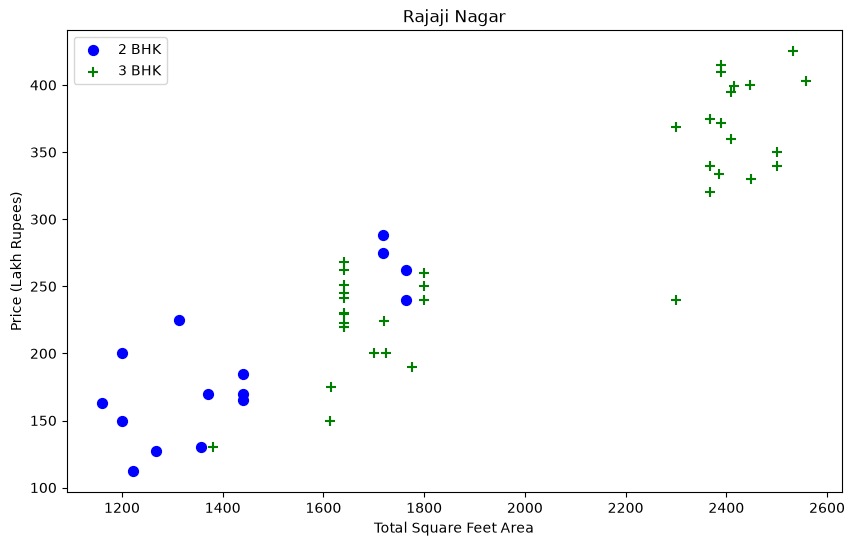

In [86]:
import matplotlib.pyplot as plt

# Scatter plot: total_sqft vs price, for 2 BHK and 3 BHK in one location
def plot_scatter_chart(df, location):
    bhk2 = df[(df.location == location) & (df.bhk == 2)]
    bhk3 = df[(df.location == location) & (df.bhk == 3)]
    plt.figure(figsize=(10, 6))
    plt.scatter(bhk2.total_sqft, bhk2.price, color='blue', label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft, bhk3.price, color='green', marker='+', label='3 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Rupees)")
    plt.title(location)
    plt.legend()
    plt.show()

plot_scatter_chart(house_df, "Rajaji Nagar")

In [87]:
import numpy as np

def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk - 1)
            if stats and stats['count'] > 5:
                # Mark for removal: rows where price_per_sqft is less than
                # the previous BHK's average (i.e. priced like a smaller home)
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[bhk_df.price_per_sqft < stats['mean']].index.values
                )
    return df.drop(exclude_indices, axis='index')

house_df = remove_bhk_outliers(house_df)
house_df.shape

(7875, 8)

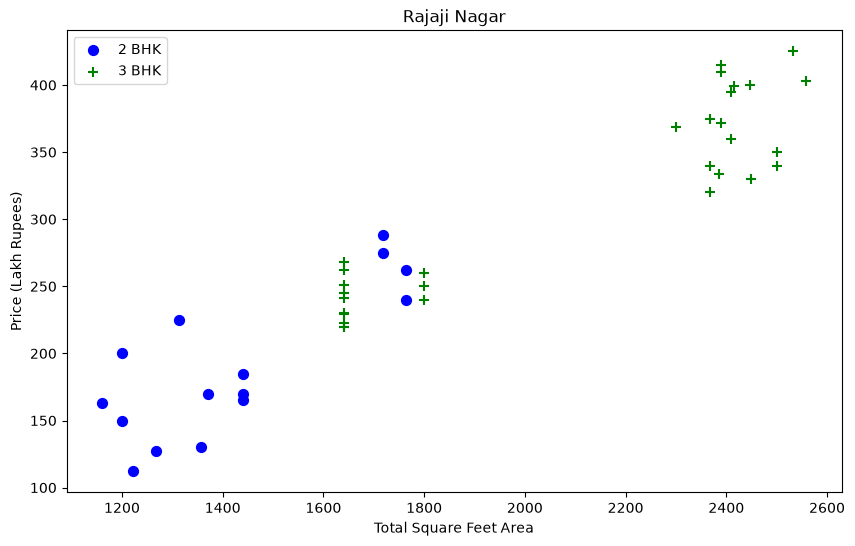

In [88]:
plot_scatter_chart(house_df, "Rajaji Nagar")

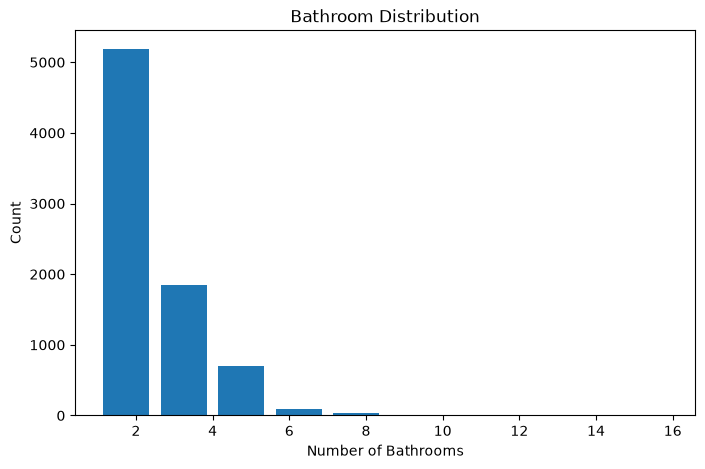

,area_type,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
819,Plot Area,BTM 1st Stage,3300.0,14.0,2.0,500.0,9.0,15151.515152
2047,Built-up Area,Chikkabanavar,2460.0,7.0,2.0,80.0,4.0,3252.032520
6367,Built-up Area,Nagasandra,7000.0,8.0,2.0,450.0,4.0,6428.571429
7732,Super built-up Area,Sathya Sai Layout,11338.0,9.0,1.0,1000.0,6.0,8819.897689
8245,Super built-up Area,Thanisandra,1806.0,6.0,2.0,116.0,3.0,6423.034330


In [89]:
# Visualize the distribution of bath count
plt.figure(figsize=(8,5))
plt.hist(house_df['bath'], rwidth=0.8)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")
plt.title("Bathroom Distribution")
plt.show()

# Find houses where bath count is unusually high vs bhk
house_df[house_df.bath > house_df.bhk + 2]

In [90]:
house_df = house_df[house_df.bath <= house_df.bhk + 2]
house_df.shape

(7870, 8)

In [91]:
house_df = house_df.drop(['area_type', 'balcony', 'price_per_sqft'], axis=1)
house_df.head()

,location,total_sqft,bath,price,bhk
0,Devarabeesana Halli,1100.0,2.0,70.0,2.0
1,Devarabeesana Halli,1672.0,3.0,150.0,3.0
2,Devarabeesana Halli,1750.0,3.0,149.0,3.0
3,Devarabeesana Halli,1750.0,3.0,150.0,3.0
5,Devarachikkanahalli,1250.0,2.0,40.0,2.0


In [92]:
# Count how many rows belong to each location, sorted descending
location_stats = house_df['location'].apply(lambda x: x.strip()).value_counts(ascending=False)
location_stats.head(10)

location
Whitefield               246
Sarjapur  Road           195
Electronic City          163
Raja Rajeshwari Nagar    140
Uttarahalli              120
Haralur Road             118
Marathahalli             116
Bannerghatta Road        109
Hennur Road              109
Hebbal                   108
Name: count, dtype: int64

In [93]:
location_stats_less_than_10 = location_stats[location_stats <= 10]
len(location_stats_less_than_10)

603

In [94]:
# First, clean up whitespace in location names
house_df['location'] = house_df['location'].apply(lambda x: x.strip())

# Replace any location that appears <= 10 times with "other"
house_df['location'] = house_df['location'].apply(
    lambda x: 'other' if x in location_stats_less_than_10 else x
)

# Check how many unique locations remain now
len(house_df['location'].unique())

172

In [95]:
# Create one-hot encoded columns for location
dummies = pd.get_dummies(house_df['location'])
dummies.head()

,1st Phase JP Nagar,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,Abbigere,Akshaya Nagar,Ambalipura,Ambedkar Nagar,...,Varthur,Vidyaranyapura,Vijayanagar,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yeshwanthpur,other
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [96]:
# Join the dummy columns to our main dataframe
house_df = pd.concat([house_df, dummies.drop('other', axis=1)], axis=1)

# Now drop the original 'location' text column - we don't need it anymore
house_df = house_df.drop('location', axis=1)

house_df.head()
print(house_df.shape)

(7870, 175)


In [97]:
# X = everything except price (our input features)
X = house_df.drop('price', axis=1)

# y = just the price column (what we want to predict)
y = house_df['price']

print(X.shape)
print(y.shape)
X.head()

(7870, 174)
(7870,)


,total_sqft,bath,bhk,1st Phase JP Nagar,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,Abbigere,...,Uttarahalli,Varthur,Vidyaranyapura,Vijayanagar,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yeshwanthpur
0,1100.0,2.0,2.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1672.0,3.0,3.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1750.0,3.0,3.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1750.0,3.0,3.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,1250.0,2.0,2.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (6296, 174)
Test set size: (1574, 174)


In [102]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train it using the training data
model.fit(X_train, y_train)

# Check how well it performs on the TEST set (data it hasn't seen)
model.score(X_test, y_test)

0.6206337671573348

In [104]:
from sklearn.model_selection import ShuffleSplit, cross_val_score

# Create 5 different random train/test splits (80/20 each time)
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

# Train and test the model 5 times, once per split, and return all 5 scores
scores = cross_val_score(LinearRegression(), X, y, cv=cv)
scores

array([0.70123594, 0.6296705 , 0.63719642, 0.70349413, 0.69415581])

In [105]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=10)
rf_model.fit(X_train, y_train)
rf_model.score(X_test, y_test)

0.7315543860498591

In [109]:
rf_scores = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=10), X, y, cv=cv)
rf_scores

array([0.47507845, 0.7666643 , 0.72210733, 0.54701021, 0.49143396])

In [111]:
from sklearn.linear_model import Lasso

lasso_scores = cross_val_score(Lasso(), X, y, cv=cv)
lasso_scores

array([0.64938798, 0.58056882, 0.60832934, 0.63942263, 0.65522087])

In [112]:
final_model = LinearRegression()
final_model.fit(X, y)

print("Model trained on", X.shape[0], "houses")

Model trained on 7870 houses


In [115]:
import numpy as np

def predict_price(location, sqft, bath, bhk):
    # Find the column index for this location (if it exists)
    loc_index = np.where(X.columns == location)[0]

    # Create an array of zeros with one slot per feature column
    x = np.zeros(len(X.columns))
    
    # Set the basic numeric features (first 3 columns: total_sqft, bath, bhk)
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    
    # If the location exists as a column, set it to 1
    if len(loc_index) > 0:
        x[loc_index[0]] = 1

    return final_model.predict([x])[0]

In [116]:
print(predict_price('Whitefield', 1000, 2, 2))
print(predict_price('Indira Nagar', 1000, 2, 2))
print(predict_price('1st Phase JP Nagar', 1500, 3, 3))

36.01523911965762
167.08721375616636
122.4401313766346


C:\Users\best\OracleRealty\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\best\OracleRealty\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\best\OracleRealty\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [117]:
def predict_price(location, sqft, bath, bhk):
    loc_index = np.where(X.columns == location)[0]

    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk

    if len(loc_index) > 0:
        x[loc_index[0]] = 1

    # Wrap in a DataFrame with the same column names as X, to avoid the warning
    x_df = pd.DataFrame([x], columns=X.columns)
    return final_model.predict(x_df)[0]

print(predict_price('Whitefield', 1000, 2, 2))
print(predict_price('Indira Nagar', 1000, 2, 2))
print(predict_price('1st Phase JP Nagar', 1500, 3, 3))

36.01523911965762
167.08721375616636
122.4401313766346


In [118]:
import joblib
import os

# Create a 'model' folder if it doesn't exist
os.makedirs('../model', exist_ok=True)

# Save the trained model
joblib.dump(final_model, '../model/house_price_model.pkl')

# Save the column names (needed later to build prediction inputs correctly)
joblib.dump(list(X.columns), '../model/model_columns.pkl')

print("Model and columns saved successfully!")

Model and columns saved successfully!
